# Chapter 6: Product Recommendation Engine

  ## The Story 

  We now know who each customer is (segment) and whether they'll churn.
  But insight without action has no business value.

  The recommendation engine is the action layer — it answers:
  **"What should we offer this customer right now?"**

  A Champion who buys kitchenware might love a new premium cookware line.
  An At-Risk customer who bought once might be won back with a discount
  on something similar to their only purchase.

  ## Our Approach: Two-Layer Hybrid

  Not every customer has enough purchase history for personalized recommendations.
  We handle this with two layers:

  | Layer | Method | Who it serves |
  |---|---|---|
  | Layer 1 | Item-based Collaborative Filtering | Customers with 2+ orders |
  | Layer 2 | Segment Top Products | One-time buyers — what their segment loves |

  This mirrors how production recommendation systems actually work —
  personalized where possible, sensible fallback where not.

  ---
  Run all cells and share:
  1. The output of Cell 10 (sample recommendation for one customer)
  2. The segment top products table (Cell 12)
  3. The plot

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
print('Libraries loaded.')

Libraries loaded.


## Step 1 — Load Data

  We need two things:
  - cleaned_retail.csv: the full transaction history (what each customer bought)
  - rfm_segmented.csv: the segment each customer belongs to

In [2]:
df  = pd.read_csv('../data/cleaned_retail.csv', parse_dates=['InvoiceDate'])
rfm = pd.read_csv('../data/rfm_segmented.csv')
print('Transactions shape:', df.shape)
print('Customers shape:   ', rfm.shape)
print('\nSegment distribution:')
print(rfm['SegmentName'].value_counts())
print('\nSample transactions:')
print(df[['CustomerID','Description','Quantity','TotalAmount']].head(5))

Transactions shape: (397884, 9)
Customers shape:    (3604, 19)

Segment distribution:
SegmentName
At-Risk      1395
Loyal        1223
Lost          958
Champions      28
Name: count, dtype: int64

Sample transactions:
   CustomerID                          Description  Quantity  TotalAmount
0       17850   WHITE HANGING HEART T-LIGHT HOLDER         6        15.30
1       17850                  WHITE METAL LANTERN         6        20.34
2       17850       CREAM CUPID HEARTS COAT HANGER         8        22.00
3       17850  KNITTED UNION FLAG HOT WATER BOTTLE         6        20.34
4       17850       RED WOOLLY HOTTIE WHITE HEART.         6        20.34


## Step 2 — Build the Customer-Product Matrix

  We reshape the transaction data into a matrix where:
  - Each ROW is a customer
  - Each COLUMN is a product
  - Each VALUE is how many times that customer bought that product

  This is the foundation of collaborative filtering.
  A customer who bought "WHITE HANGING HEART T-LIGHT HOLDER" and
  "CREAM CUPID HEARTS COAT HANGER" is similar to another customer
  who bought both — and we can recommend what the second customer
  bought next that the first hasn't tried yet.

In [3]:
# Use only customers we have segments for
valid_customers = set(rfm['CustomerID'].unique())
df_filtered = df[df['CustomerID'].isin(valid_customers)].copy()
# Build customer-product matrix (presence: 1 if bought, 0 if not)
customer_product = df_filtered.pivot_table(
    index   = 'CustomerID',
    columns = 'Description',
    values  = 'Quantity',
    aggfunc = 'sum'
).fillna(0)

# Binarize — we care about whether they bought it, not how many
customer_product = (customer_product > 0).astype(int)
print('Customer-Product Matrix shape:', customer_product.shape)
print(f'{customer_product.shape[0]} customers × {customer_product.shape[1]} products')


Customer-Product Matrix shape: (3604, 3867)
3604 customers × 3867 products


## Step 3 — Item-Item Cosine Similarity

  Cosine similarity measures how similar two products are based on
  who buys them. If customers who buy Product A also tend to buy
  Product B, their cosine similarity will be high.

  We compute this for every pair of products — giving us a
  "similarity map" of the entire product catalogue.

  Score of 1.0 = always bought together
  Score of 0.0 = never bought by the same customer

In [4]:
# Compute item-item cosine similarity
item_similarity = cosine_similarity(customer_product.T)
item_sim_df = pd.DataFrame(
    item_similarity,
    index   = customer_product.columns,
    columns = customer_product.columns
)
print('Item similarity matrix shape:', item_sim_df.shape)
print('\nSample — top 5 products similar to "WHITE HANGING HEART T-LIGHT HOLDER":')
sample_product = 'WHITE HANGING HEART T-LIGHT HOLDER'
if sample_product in item_sim_df.columns:
    similar = item_sim_df[sample_product].sort_values(ascending=False)[1:6]
    print(similar)

Item similarity matrix shape: (3867, 3867)

Sample — top 5 products similar to "WHITE HANGING HEART T-LIGHT HOLDER":
Description
RED HANGING HEART T-LIGHT HOLDER     0.544522
CANDLEHOLDER PINK HANGING HEART      0.492356
HEART OF WICKER LARGE                0.430916
HEART OF WICKER SMALL                0.394856
WOODEN PICTURE FRAME WHITE FINISH    0.374977
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64


## Step 4 — Generate Personalised Recommendations (Layer 1)

  For each customer with 2+ orders, we:
  1. Find all products they have bought
  2. For each product they bought, look up the most similar products
  3. Rank candidate products by their average similarity score
  4. Remove products they already own
  5. Return the top 5 recommendations

  This is exactly how Amazon's "Customers who bought this also bought" works.


In [5]:
def get_recommendations(customer_id, top_n=5):
      if customer_id not in customer_product.index:
          return []

      bought      = customer_product.loc[customer_id]
      bought_items = bought[bought == 1].index.tolist()

      if not bought_items:
          return []
  
      # Average similarity across all items the customer bought
      sim_scores = item_sim_df[bought_items].mean(axis=1)

      # Remove already-bought items
      sim_scores = sim_scores.drop(labels=bought_items, errors='ignore')

      return sim_scores.nlargest(top_n).index.tolist()


# Generate for all customers with Frequency >= 2
repeat_customers = rfm[rfm['Frequency'] >= 2]['CustomerID'].tolist()
recs_cf = {}
for cid in repeat_customers:
    recs = get_recommendations(cid)
    if recs:
        recs_cf[cid] = recs
print(f'Generated collaborative filtering recommendations for {len(recs_cf):,} customers')
print('\nSample recommendation for one customer:')
sample_cid = list(recs_cf.keys())[0]
print(f'CustomerID {sample_cid}:')
for i, r in enumerate(recs_cf[sample_cid], 1):
    print(f'  {i}. {r}')

Generated collaborative filtering recommendations for 2,162 customers

Sample recommendation for one customer:
CustomerID 12347:
  1. PACK OF 72 RETROSPOT CAKE CASES
  2. LUNCH BAG RED RETROSPOT
  3. SET OF 3 REGENCY CAKE TINS
  4. LUNCH BAG SPACEBOY DESIGN 
  5. LUNCH BAG ALPHABET DESIGN


## Step 5 — Segment Top Products (Layer 2 Fallback)

  For one-time buyers with no purchase history to learn from,
  we recommend the most popular products within their segment.

  Champions buy different things than Lost customers — segment-level
  popularity is a meaningful, targeted fallback rather than just
  recommending the site-wide bestsellers to everyone.

In [6]:
# Merge segment info into transactions
df_seg = df_filtered.merge(rfm[['CustomerID','SegmentName']], on='CustomerID', how='left')
# Top 5 products per segment by number of unique customers who bought them
segment_top = (
    df_seg.groupby(['SegmentName','Description'])['CustomerID']
    .nunique()
    .reset_index()
    .rename(columns={'CustomerID':'BuyerCount'})
    .sort_values(['SegmentName','BuyerCount'], ascending=[True, False])
)
top5_per_segment = (
    segment_top.groupby('SegmentName')
    .head(5)
    .reset_index(drop=True)
)

print('Top 5 products per segment:')
print(top5_per_segment.to_string(index=False))

Top 5 products per segment:
SegmentName                         Description  BuyerCount
    At-Risk            REGENCY CAKESTAND 3 TIER         264
    At-Risk  WHITE HANGING HEART T-LIGHT HOLDER         225
    At-Risk       BAKING SET 9 PIECE RETROSPOT          208
    At-Risk                       PARTY BUNTING         208
    At-Risk       ASSORTED COLOUR BIRD ORNAMENT         201
  Champions            REGENCY CAKESTAND 3 TIER          19
  Champions  WHITE HANGING HEART T-LIGHT HOLDER          19
  Champions             JUMBO BAG RED RETROSPOT          18
  Champions     PACK OF 72 RETROSPOT CAKE CASES          17
  Champions SET/20 RED RETROSPOT PAPER NAPKINS           16
       Lost  WHITE HANGING HEART T-LIGHT HOLDER         155
       Lost            REGENCY CAKESTAND 3 TIER         125
       Lost       ASSORTED COLOUR BIRD ORNAMENT         103
       Lost     NATURAL SLATE HEART CHALKBOARD           96
       Lost                       PARTY BUNTING          93
      Loyal 

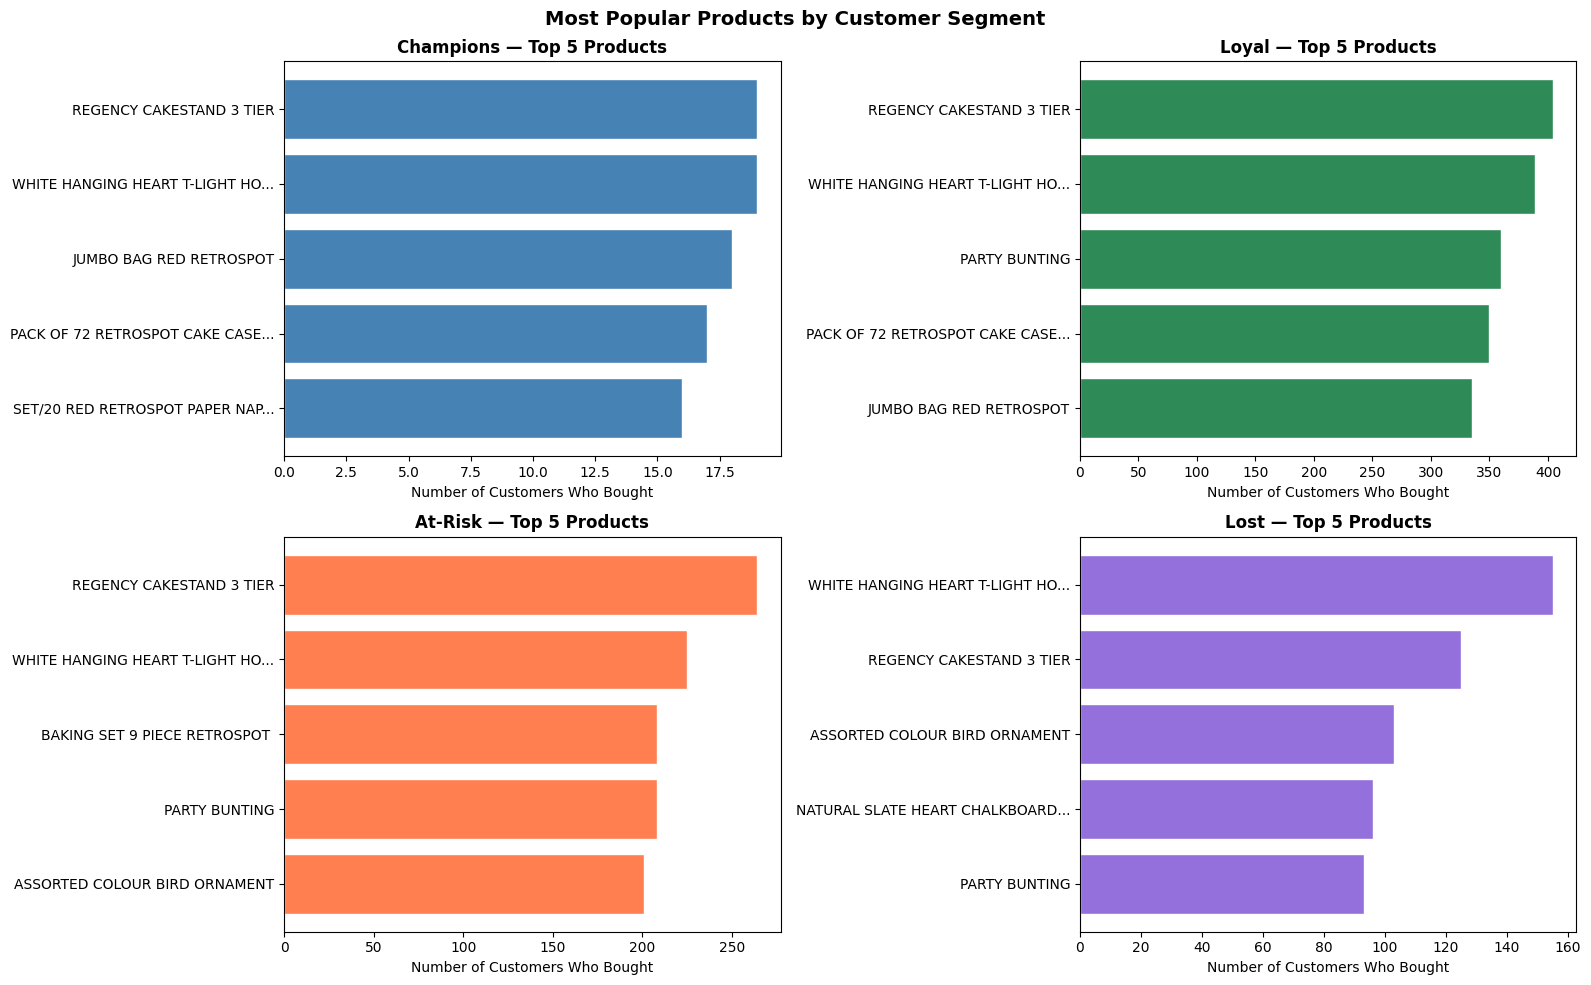

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
segments = ['Champions', 'Loyal', 'At-Risk', 'Lost']
colors   = ['steelblue', 'seagreen', 'coral', 'mediumpurple']
for ax, seg, color in zip(axes, segments, colors):
    data = top5_per_segment[top5_per_segment['SegmentName'] == seg]
    labels = [d[:30] + '...' if len(d) > 30 else d for d in data['Description']]
    ax.barh(labels, data['BuyerCount'], color=color, edgecolor='white')
    ax.set_title(f'{seg} — Top 5 Products', fontweight='bold')
    ax.set_xlabel('Number of Customers Who Bought')
    ax.invert_yaxis()
plt.suptitle('Most Popular Products by Customer Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/segment_recommendations.png', dpi=150)
plt.show()

In [8]:
# Build final recommendations table
rows = []

for _, customer in rfm.iterrows():
    cid     = customer['CustomerID']
    segment = customer['SegmentName']
    if cid in recs_cf:
        # Layer 1: personalised
        rec_products = recs_cf[cid]
        method       = 'Collaborative Filtering'
    else:
        # Layer 2: segment fallback
        seg_products = top5_per_segment[
            top5_per_segment['SegmentName'] == segment
        ]['Description'].tolist()
        rec_products = seg_products
        method       = 'Segment Fallback'
    for rank, product in enumerate(rec_products, 1):
        rows.append({
            'CustomerID'  : cid,
            'SegmentName' : segment,
            'Rank'        : rank,
            'Recommended' : product,
            'Method'      : method
        })
recommendations = pd.DataFrame(rows)
recommendations.to_csv('../data/recommendations.csv', index=False)
print('Saved: recommendations.csv')
print('Shape:', recommendations.shape)
print('\nMethod breakdown:')
print(recommendations.drop_duplicates('CustomerID')['Method'].value_counts())
print('\nStep 6 complete. Next: Chapter 7 — Revenue Forecasting')

Saved: recommendations.csv
Shape: (18020, 5)

Method breakdown:
Method
Collaborative Filtering    2162
Segment Fallback           1442
Name: count, dtype: int64

Step 6 complete. Next: Chapter 7 — Revenue Forecasting


**2,162 customers** received personalised recommendations via collaborative
  filtering — the engine found enough purchase history to make individual suggestions.
  **1,442 customers** (mostly one-time buyers) received segment-level fallback recommendations.

  **The plot reveals something interesting:** "Regency Cakestand 3 Tier" and
  "White Hanging Heart T-Light Holder" appear in all four segments —
  these are the universal bestsellers that transcend customer type.

  But the differences matter:
  - Champions and Loyal share nearly identical top products — Loyal customers
    are behaviorally on their way to becoming Champions. Same taste, less frequency.
  - Lost customers skew toward decorative/gift items (Slate Chalkboard, Bird Ornament)
    — likely one-time gift purchasers who had no reason to return.
  - At-Risk includes the Baking Set — slightly more functional,
    suggesting a different shopping motivation than the gift buyers in Lost.

  **Business application:** The At-Risk segment should receive personalised
  outreach featuring products similar to their past purchases — not generic
  bestsellers. A customer who bought baking supplies wants baking recommendations,
  not a chalkboard.